In [8]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from scipy.stats import zscore
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt

data=({
    'patient_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'age': [25, 30, np.nan, 50, 35, 42, 28, np.nan, 55, 48],
    'gender': ['Male', 'Female', 'Male', np.nan, 'Male', 'Female', 'Male', 'Female', np.nan, 'Male'],
    'region': ['North', 'South', np.nan, 'West', 'North', 'East', 'South', 'West', 'North', np.nan],
    'bmi': [22.5, 27.1, 30.2, np.nan, 26.4, 24.8, 50.0, 23.5, 5.0, 28.7],
    'blood_pressure': [120, 130, 140, 125, 135, 128, 250, 122, 118, 220],
    'cholesterol': [180, 210, np.nan, 190, 220, 200, 400, 185, 50, np.nan],
    'glucose': [90, 100, 110, np.nan, 105, 95, 300, 92, 30, np.nan],
    'disease_risk': [0, 1, 1, 0, 1, 0, 1, 0, 1, 1]
})
df=pd.DataFrame(data)
print(df)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())



   patient_id   age  gender region   bmi  blood_pressure  cholesterol  \
0           1  25.0    Male  North  22.5             120        180.0   
1           2  30.0  Female  South  27.1             130        210.0   
2           3   NaN    Male    NaN  30.2             140          NaN   
3           4  50.0     NaN   West   NaN             125        190.0   
4           5  35.0    Male  North  26.4             135        220.0   
5           6  42.0  Female   East  24.8             128        200.0   
6           7  28.0    Male  South  50.0             250        400.0   
7           8   NaN  Female   West  23.5             122        185.0   
8           9  55.0     NaN  North   5.0             118         50.0   
9          10  48.0    Male    NaN  28.7             220          NaN   

   glucose  disease_risk  
0     90.0             0  
1    100.0             1  
2    110.0             1  
3      NaN             0  
4    105.0             1  
5     95.0             0  
6    30

In [9]:
#part a
#Simple Imputer (Numerical): Replace BMI with Mean
mean_imputer = SimpleImputer(strategy='mean')
df['bmi'] = mean_imputer.fit_transform(df[['bmi']])

print("\nBMI after Mean Imputation:")
print(df['bmi'])


BMI after Mean Imputation:
0    22.500000
1    27.100000
2    30.200000
3    26.466667
4    26.400000
5    24.800000
6    50.000000
7    23.500000
8     5.000000
9    28.700000
Name: bmi, dtype: float64


In [10]:
#Simple Imputer (Categorical): Replace Region with Most Frequent Value
cat_imputer = SimpleImputer(strategy='most_frequent')
df['region'] = cat_imputer.fit_transform(df[['region']]).ravel()

print("\nRegion after Imputation:")
print(df['region'])


Region after Imputation:
0    North
1    South
2    North
3     West
4    North
5     East
6    South
7     West
8    North
9    North
Name: region, dtype: str


In [26]:
#Most Frequent Imputation for Gender
gender_imputer = SimpleImputer(strategy='most_frequent')

df['gender'] = gender_imputer.fit_transform(df[['gender']]).ravel()

print("\nGender after Imputation:")
print(df['gender'])


Gender after Imputation:
0      Male
1    Female
2      Male
3      Male
4      Male
5    Female
6      Male
7    Female
8      Male
9      Male
Name: gender, dtype: str


In [11]:
#Missing Indicator + Random Sample Imputation
# Missing Indicator
df['age_missing'] = df['age'].isnull().astype(int)

# Random Sample Imputation
random_sample = df['age'].dropna().sample(
    df['age'].isnull().sum(),
    random_state=42
)

random_sample.index = df[df['age'].isnull()].index

df.loc[df['age'].isnull(), 'age'] = random_sample

print("\nAge after Random Sample Imputation:")
print(df['age'])


Age after Random Sample Imputation:
0    25.0
1    30.0
2    30.0
3    50.0
4    35.0
5    42.0
6    28.0
7    28.0
8    55.0
9    48.0
Name: age, dtype: float64


In [12]:
#KNN Imputer

# Encode categorical columns
df['gender'] = df['gender'].map({'Male':0,'Female':1})
df['region'] = df['region'].map({'North':0,'South':1,'East':2,'West':3})

knn = KNNImputer(n_neighbors=2)

cols = ['age','gender','region','bmi','cholesterol','glucose']

df[cols] = knn.fit_transform(df[cols])

print("\nAfter KNN Imputation")
print(df)


After KNN Imputation
   patient_id   age  gender  region        bmi  blood_pressure  cholesterol  \
0           1  25.0     0.0     0.0  22.500000             120        180.0   
1           2  30.0     1.0     1.0  27.100000             130        210.0   
2           3  30.0     0.0     0.0  30.200000             140        215.0   
3           4  50.0     0.5     3.0  26.466667             125        190.0   
4           5  35.0     0.0     0.0  26.400000             135        220.0   
5           6  42.0     1.0     2.0  24.800000             128        200.0   
6           7  28.0     0.0     1.0  50.000000             250        400.0   
7           8  28.0     1.0     3.0  23.500000             122        185.0   
8           9  55.0     0.0     0.0   5.000000             118         50.0   
9          10  48.0     0.0     0.0  28.700000             220        195.0   

   glucose  disease_risk  age_missing  
0     90.0             0            0  
1    100.0             1    

In [13]:
#part b
#Z-Score 
df_z = df.copy()

z_scores = zscore(df_z[['cholesterol','glucose']])

outliers = (abs(z_scores)>3)

print("\nZ-Score Outliers:")
print(outliers)


Z-Score Outliers:
[[False False]
 [False False]
 [False False]
 [False False]
 [False False]
 [False False]
 [False False]
 [False False]
 [False False]
 [False False]]


In [14]:
#IQR 
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['bmi'] < lower) | (df['bmi'] > upper)]

print("\nBMI Outliers:")
print(outliers[['patient_id','bmi']])



BMI Outliers:
   patient_id   bmi
6           7  50.0
8           9   5.0



After Percentile Method:
   patient_id   age  gender  region        bmi  blood_pressure  cholesterol  \
0           1  25.0     0.0     0.0  22.500000             120        180.0   
1           2  30.0     1.0     1.0  27.100000             130        210.0   
2           3  30.0     0.0     0.0  30.200000             140        215.0   
3           4  50.0     0.5     3.0  26.466667             125        190.0   
4           5  35.0     0.0     0.0  26.400000             135        220.0   
5           6  42.0     1.0     2.0  24.800000             128        200.0   
7           8  28.0     1.0     3.0  23.500000             122        185.0   
9          10  48.0     0.0     0.0  28.700000             220        195.0   

   glucose  disease_risk  age_missing  
0     90.0             0            0  
1    100.0             1            0  
2    110.0             1            1  
3     93.5             0            0  
4    105.0             1            0  
5     95.0            

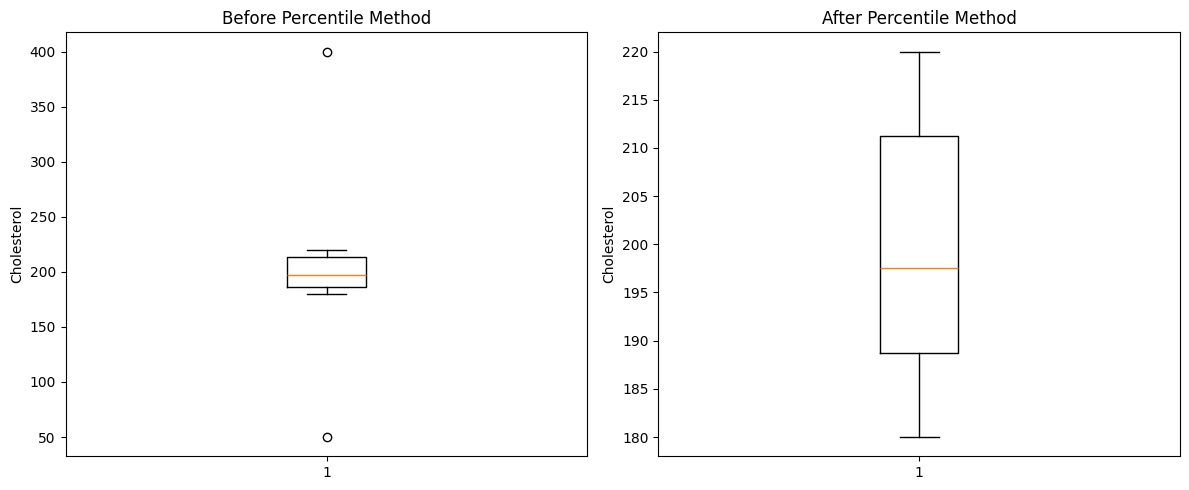

In [15]:
#Percentile 
lower_limit = df['cholesterol'].quantile(0.01)
upper_limit = df['cholesterol'].quantile(0.99)

df_percentile = df[
    (df['cholesterol'] >= lower_limit) &
    (df['cholesterol'] <= upper_limit)
]

print("\nAfter Percentile Method:")
print(df_percentile)

# Plot Boxplots Before and After
plt.figure(figsize=(12,5))

# Before removing outliers
plt.subplot(1,2,1)
plt.boxplot(df['cholesterol'])
plt.title("Before Percentile Method")
plt.ylabel("Cholesterol")

# After removing outliers
plt.subplot(1,2,2)
plt.boxplot(df_percentile['cholesterol'])
plt.title("After Percentile Method")
plt.ylabel("Cholesterol")

plt.tight_layout()
plt.show()

In [16]:
#Winsorization Technique
df['glucose_winsorized'] = winsorize(df['glucose'], limits=[0.05,0.05])

print("\nWinsorized Glucose:")
print(df[['glucose','glucose_winsorized']])


Winsorized Glucose:
   glucose  glucose_winsorized
0     90.0                90.0
1    100.0               100.0
2    110.0               110.0
3     93.5                93.5
4    105.0               105.0
5     95.0                95.0
6    300.0               300.0
7     92.0                92.0
8     30.0                30.0
9    100.0               100.0


In [17]:
# Remove helper column
if 'age_missing' in df.columns:
    df.drop('age_missing', axis=1, inplace=True)

print("\nFinal Clean Dataset")
print(df)

# Save Dataset
df.to_csv("final_clean_dataset.csv", index=False)

print("\nDataset saved successfully!")


Final Clean Dataset
   patient_id   age  gender  region        bmi  blood_pressure  cholesterol  \
0           1  25.0     0.0     0.0  22.500000             120        180.0   
1           2  30.0     1.0     1.0  27.100000             130        210.0   
2           3  30.0     0.0     0.0  30.200000             140        215.0   
3           4  50.0     0.5     3.0  26.466667             125        190.0   
4           5  35.0     0.0     0.0  26.400000             135        220.0   
5           6  42.0     1.0     2.0  24.800000             128        200.0   
6           7  28.0     0.0     1.0  50.000000             250        400.0   
7           8  28.0     1.0     3.0  23.500000             122        185.0   
8           9  55.0     0.0     0.0   5.000000             118         50.0   
9          10  48.0     0.0     0.0  28.700000             220        195.0   

   glucose  disease_risk  glucose_winsorized  
0     90.0             0                90.0  
1    100.0     